In [31]:
import pandas as pd
import numpy as np
from collections import Counter
import lightgbm as lgb
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.base import ClassifierMixin

### Original small preprocessing

In [32]:
df_spotify = pd.read_csv("../data/spotify_no_null.csv")

df_spotify['is_hit'] = (df_spotify['popularity'] >= 70).astype(int)
df_spotify = df_spotify.drop('popularity', axis=1)

df_spotify = df_spotify.rename(columns={'duration_ms': 'duration_s'})
df_spotify['duration_s'] = df_spotify['duration_s'] / 1000.0

In [33]:
df_spotify.head()

,id,track_id,artists,album_name,track_name,duration_s,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,is_hit
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,230.666,False,0.676,0.4610,1,...,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic,1
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,149.610,False,0.420,0.1660,1,...,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic,0
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,210.826,False,0.438,0.3590,0,...,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic,0
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,201.933,False,0.266,0.0596,0,...,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic,1
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,198.853,False,0.618,0.4430,2,...,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic,1


### *track_genre* preprocessing and engineering
Dataset contains a total of 114 unique genre entries, to simplify usage all subgenres are reunited under their main genre. Specific genres are labeled after the most similar main genre, based on technical song features.

In [34]:
genres = df_spotify['track_genre'].unique()
genres

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

In [35]:
Counter(df_spotify['track_genre'])

Counter({'acoustic': 1000,
         'afrobeat': 1000,
         'alt-rock': 1000,
         'alternative': 1000,
         'ambient': 1000,
         'anime': 1000,
         'black-metal': 1000,
         'bluegrass': 1000,
         'blues': 1000,
         'brazil': 1000,
         'breakbeat': 1000,
         'british': 1000,
         'cantopop': 1000,
         'chicago-house': 1000,
         'children': 1000,
         'chill': 1000,
         'classical': 1000,
         'club': 1000,
         'comedy': 1000,
         'country': 1000,
         'dance': 1000,
         'dancehall': 1000,
         'death-metal': 1000,
         'deep-house': 1000,
         'detroit-techno': 1000,
         'disco': 1000,
         'disney': 1000,
         'drum-and-bass': 1000,
         'dub': 1000,
         'dubstep': 1000,
         'edm': 1000,
         'electro': 1000,
         'electronic': 1000,
         'emo': 1000,
         'folk': 1000,
         'forro': 1000,
         'french': 1000,
         'funk': 1000,

In the first preprocessing stage, genres are grouped into 7 main categories: **Rock**, **Pop**, **Blues**, **Hip-Hop**, **Latin**, **Classical** and **Dance**. Songs for which genre is not directly groupable are assigned **Other**.

In [36]:
def group_genres(genres):
    categories = {
        "rock": ["emo", "garage", "goth", "grunge", "metal", "punk", "rock"],

        "pop": ["pop", "songwriter"],

        "blues": ["blue", "funk", "gospel", "jazz", "soul"],

        "hip-hop": ["hip-hop", "r-n-b"],

        "latin": ["brazil", "forro", "latin", "mpb", "pagode", "reggaeton", "salsa", "samba", "sertanejo", "tango"],

        "classical": ["classical", "opera", "piano"],

        "dance": ["breakbeat", "drum-and-bass", "dance", "disco", "dub", "edm", "electro", "hardcore", "hardstyle", "house", "idm", "techno", "trance", "trip-hop"]
    }

    # Initialize groups
    grouped = {key: [] for key in categories}
    grouped["other"] = []

    # Genres matching
    for g in genres:
        found = False
        for cat, items in categories.items():
            if any(k in g for k in items):
                grouped[cat].append(g)
                found = True
                break
        if not found:
            grouped["other"].append(g)

    return grouped

grouped = group_genres(genres)

for cat, items in grouped.items():
    print(cat, "=>", items)

mapped_genres = []
for genre in df_spotify['track_genre']:
    for cat, items in grouped.items():
        if genre in items:
            mapped_genres.append(cat)

df_spotify['track_genre'] = mapped_genres
Counter(df_spotify['track_genre'])

rock => ['alt-rock', 'black-metal', 'death-metal', 'emo', 'garage', 'goth', 'grunge', 'hard-rock', 'heavy-metal', 'j-rock', 'metal', 'metalcore', 'psych-rock', 'punk-rock', 'punk', 'rock-n-roll', 'rock', 'rockabilly']
pop => ['cantopop', 'indie-pop', 'j-pop', 'k-pop', 'mandopop', 'pop-film', 'pop', 'power-pop', 'singer-songwriter', 'songwriter', 'synth-pop']
blues => ['bluegrass', 'blues', 'funk', 'gospel', 'jazz', 'soul']
hip-hop => ['hip-hop', 'r-n-b']
latin => ['brazil', 'forro', 'latin', 'latino', 'mpb', 'pagode', 'reggaeton', 'salsa', 'samba', 'sertanejo', 'tango']
classical => ['classical', 'opera', 'piano']
dance => ['breakbeat', 'chicago-house', 'dance', 'dancehall', 'deep-house', 'detroit-techno', 'disco', 'drum-and-bass', 'dub', 'dubstep', 'edm', 'electro', 'electronic', 'hardcore', 'hardstyle', 'house', 'idm', 'j-dance', 'minimal-techno', 'progressive-house', 'techno', 'trance', 'trip-hop']
other => ['acoustic', 'afrobeat', 'alternative', 'ambient', 'anime', 'british', 'chil

Counter({'other': 40000,
         'dance': 23000,
         'rock': 18000,
         'latin': 11000,
         'pop': 10999,
         'blues': 6000,
         'classical': 3000,
         'hip-hop': 2000})

Tracks with genre **Other** are now relabeled based on a multiclass LightGBModel trained on the 7 main genres, considering only the audio-specific features.

In [37]:
MAIN_GENRES = ["rock", "pop", "blues", "hip-hop", "latin", "classical", "dance"]

audio_features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
                  'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_s']

df_main = df_spotify[df_spotify['track_genre'].isin(MAIN_GENRES)].copy()
df_other = df_spotify[df_spotify['track_genre'] == "other"].copy()

X_main = df_main[audio_features]
y_main = df_main['track_genre']

In [38]:
X_train, X_val, y_train, y_val = train_test_split(
    X_main, y_main,
    test_size=0.2,
    random_state=42,
    stratify=y_main
)

In [39]:
lgbm_genre = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(MAIN_GENRES),
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    class_weight="balanced"
)

lgbm_genre.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [40]:
y_val_pred = lgbm_genre.predict(X_val)

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

       blues       0.43      0.48      0.45      1200
   classical       0.67      0.76      0.71       600
       dance       0.83      0.73      0.78      4600
     hip-hop       0.19      0.39      0.25       400
       latin       0.65      0.64      0.64      2200
         pop       0.49      0.55      0.52      2200
        rock       0.72      0.65      0.68      3600

    accuracy                           0.64     14800
   macro avg       0.57      0.60      0.58     14800
weighted avg       0.67      0.64      0.65     14800



Validation phase already verified discriminative ability (e.g. on **Dance**, **Rock**, **Classical**) and structural limitations (on **Hip-Hop** given by the its support). Now, to maximize the available information, the model is retrained on the full main-genres dataset before predicting on the **Other** dataset.

In [41]:
lgbm_genre = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=len(MAIN_GENRES),
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    class_weight="balanced"
)

lgbm_genre.fit(X_main, y_main)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Genres are reassigned based on a fixed confidence threshold. Songs that do not surpass this threshold are left in **Other** and excluded from this analysis to avoid adding extreme noise.

In [42]:
X_other = df_other[audio_features]
proba_other = lgbm_genre.predict_proba(X_other)

max_proba = proba_other.max(axis=1)
pred_genre = lgbm_genre.classes_[np.argmax(proba_other, axis=1)]

CONFIDENCE_THRESHOLD = 0.65

df_other['track_genre'] = np.where(max_proba >= CONFIDENCE_THRESHOLD,
                                   pred_genre, "other")

df_other['reassignment_confidence'] = max_proba

In [43]:
coverage = (df_other['track_genre'] != "other").mean()
print(f"Reassignment coverage: {coverage:.2%}")

df_other['track_genre'].value_counts(normalize=True)

Reassignment coverage: 32.99%


track_genre
other        0.670075
classical    0.097025
dance        0.095900
rock         0.076125
latin        0.031075
pop          0.013500
blues        0.011450
hip-hop      0.004850
Name: proportion, dtype: float64

Genre distribution in dataset before and after reassignment.

In [44]:
df_spotify['track_genre'].value_counts(normalize=True)

track_genre
other        0.350880
dance        0.201756
rock         0.157896
latin        0.096492
pop          0.096483
blues        0.052632
classical    0.026316
hip-hop      0.017544
Name: proportion, dtype: float64

In [45]:
df_spotify.loc[df_other.index, 'track_genre'] = df_other['track_genre']
df_spotify['track_genre'].value_counts(normalize=True)

track_genre
dance        0.235406
other        0.235116
rock         0.184607
latin        0.107396
pop          0.101220
classical    0.060360
blues        0.056650
hip-hop      0.019246
Name: proportion, dtype: float64

In [46]:
Counter(df_spotify['track_genre'])

Counter({'dance': 26836,
         'other': 26803,
         'rock': 21045,
         'latin': 12243,
         'pop': 11539,
         'classical': 6881,
         'blues': 6458,
         'hip-hop': 2194})

**Other** genres are now relabeled based on 5-NN distance computed after 3-components PCA analysis.

In [47]:
"""from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

def classify_others_pca_knn(cols, n_components=3, k=5):
    main_categories = ["rock", "pop", "blues", "hip-hop", "latin", "classical", "dance"]

    df_main = df_spotify[df_spotify['track_genre'].isin(main_categories)].copy()
    df_others = df_spotify[df_spotify['track_genre'] == "other"].copy()

    # scaling
    scaler = StandardScaler()
    X_main_scaled = scaler.fit_transform(df_main[cols])
    X_others_scaled = scaler.transform(df_others[cols])

    # PCA
    pca = PCA(n_components=n_components)
    X_main_pca = pca.fit_transform(X_main_scaled)
    X_others_pca = pca.transform(X_others_scaled)

    # plot clusters before relabeling
    plot_pca_3d(X_main=X_main_pca, y_main=df_main['track_genre'].values,
                X_others=X_others_pca, main_categories=main_categories,
                title="PCA 3D - Before relabeling")
    
    # KNN relabeling
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_main_pca, df_main['track_genre'])

    predicted = knn.predict(X_others_pca)
    df_spotify.loc[df_others.index, 'track_genre'] = predicted

    # replot clusters after relabeling
    plot_pca_3d(X_main=X_main_pca, y_main=df_main['track_genre'].values,
                X_others=X_others_pca, main_categories=main_categories,
                assigned_labels=predicted, title="PCA 3D - After relabeling")
    
    print(f"Predicted labels: {Counter(predicted)}")
    print(f"Final genres: {Counter(df_spotify['track_genre'])}")

def plot_pca_3d(X_main, y_main, X_others, main_categories, title, assigned_labels=None):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    colors = {
        "rock": "red",
        "pop": "pink",
        "blues": "blue",
        "hip-hop": "yellow",
        "latin": "green",
        "classical": "purple",
        "dance": "orange"
    }

    for cat in main_categories:
        idx = np.where(y_main == cat)[0]
        if len(idx) > 0:
            ax.scatter(
                X_main[idx, 0], X_main[idx, 1], X_main[idx, 2],
                c=colors[cat], label=cat, alpha=0.7, marker="o"
            )

    if assigned_labels is None:
        # first plot: original "Other"
        ax.scatter(
                X_others[:, 0], X_others[:, 1], X_others[:, 2],
                c="grey", label="other", alpha=0.7, marker="o"
            )
    else:
        # second plot: reassigned labels
        for cat in main_categories:
            idx = np.where(assigned_labels == cat)[0]
            if len(idx) > 0:
                ax.scatter(
                        X_others[idx, 0], X_others[idx, 1], X_others[idx, 2],
                        c=colors[cat], label=f"{cat} (assigned)", marker="x", s=80
                    )

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.legend()
    plt.show()
    
technical_cols = ["duration_s", "danceability", "energy", "key", "loudness", "mode", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo", "time_signature"]
classify_others_pca_knn(technical_cols)"""

'from sklearn.preprocessing import StandardScaler\nfrom sklearn.decomposition import PCA\nfrom sklearn.neighbors import KNeighborsClassifier\nimport matplotlib.pyplot as plt\n\ndef classify_others_pca_knn(cols, n_components=3, k=5):\n    main_categories = ["rock", "pop", "blues", "hip-hop", "latin", "classical", "dance"]\n\n    df_main = df_spotify[df_spotify[\'track_genre\'].isin(main_categories)].copy()\n    df_others = df_spotify[df_spotify[\'track_genre\'] == "other"].copy()\n\n    # scaling\n    scaler = StandardScaler()\n    X_main_scaled = scaler.fit_transform(df_main[cols])\n    X_others_scaled = scaler.transform(df_others[cols])\n\n    # PCA\n    pca = PCA(n_components=n_components)\n    X_main_pca = pca.fit_transform(X_main_scaled)\n    X_others_pca = pca.transform(X_others_scaled)\n\n    # plot clusters before relabeling\n    plot_pca_3d(X_main=X_main_pca, y_main=df_main[\'track_genre\'].values,\n                X_others=X_others_pca, main_categories=main_categories,\n      

# Genre-specific analysis
Tracks are now grouped into 7 main genres. Some main subgenres are regrouped with their respective genre, while more specific ones were inferred by technical features similarity. Now we can apply the same analysis done on the whole dataset, but on each specific genre, to understand how technical factors defining an hit song vary.

## 1. Data Preparation & Target Definition

In [48]:
# Exclude track with unassigned genre
df_spotify_genres = df_spotify[df_spotify['track_genre'] != "other"]

In [49]:
# Drop text-based and identifier columns not used for audio feature prediction
cols_to_drop_text = ['track_id', 'artists', 'album_name', 'track_name'] 
df_spotify_genres = df_spotify_genres.drop(columns=cols_to_drop_text, errors='ignore')

for genre in set(df_spotify_genres['track_genre']):
    df_genre = df_spotify_genres[df_spotify_genres['track_genre'] == genre]
    print(f"'is_hit' Distribution in {genre} genre ({df_genre.shape[0]} entries): \n{df_genre['is_hit'].value_counts(normalize=True)}")

'is_hit' Distribution in latin genre (12243 entries): 
is_hit
0    0.962999
1    0.037001
Name: proportion, dtype: float64
'is_hit' Distribution in classical genre (6881 entries): 
is_hit
0    0.986775
1    0.013225
Name: proportion, dtype: float64
'is_hit' Distribution in rock genre (21045 entries): 
is_hit
0    0.939273
1    0.060727
Name: proportion, dtype: float64
'is_hit' Distribution in pop genre (11539 entries): 
is_hit
0    0.900858
1    0.099142
Name: proportion, dtype: float64
'is_hit' Distribution in dance genre (26836 entries): 
is_hit
0    0.956365
1    0.043635
Name: proportion, dtype: float64
'is_hit' Distribution in blues genre (6458 entries): 
is_hit
0    0.956643
1    0.043357
Name: proportion, dtype: float64
'is_hit' Distribution in hip-hop genre (2194 entries): 
is_hit
0    0.917958
1    0.082042
Name: proportion, dtype: float64


## Justification for Genre Selection for Genre-Specific Feature Sensitivity Analysis

To investigate **genre-specific drivers of hit success**, this phase focuses on a subset of musical genres selected according to **statistical robustness** and **comparability with the global analysis**.

The selection of genres was guided by two primary criteria:

1. **Sufficient sample size** ($\geq 5000$), ensuring stable model training and reliable feature importance estimates.
2. **Adequate representation of hit instances** ($\geq 3.5%$), avoiding extreme class imbalance that could undermine the interpretability of genre-specific patterns.

Based on these criteria, the analysis includes the following genres: **Pop, Rock, Blues, Dance, and Latin**.

---

### Rationale for Included Genres

The selected genres exhibit both **large sample sizes** (ranging from approximately 9,000 to over 34,000 tracks) and **hit-rate proportions close to the global average (~5%)**, as observed in the primary analysis. This consistency ensures that the genre-specific models operate under conditions comparable to the overall model, allowing meaningful comparison of feature importance profiles.

* **Pop** represents the genre with the highest hit rate (~9%), making it particularly informative for identifying acoustic and structural drivers of mainstream success.
* **Rock** and **Dance** closely align with the global hit distribution (~4–6%), offering robust contexts to examine genre-conditioned variations in success mechanisms.
* **Blues** and **Latin**, while exhibiting slightly lower hit proportions (~3–4%), still maintain sufficient positive instances to support reliable modeling, especially when class imbalance is properly accounted for during training.

Collectively, these genres provide a balanced set of stylistically distinct musical families, enabling a comparative analysis without compromising statistical reliability.

---

### Excluded Genres and Methodological Considerations

Two genres were deliberately excluded from the core genre-specific analysis:

* **Hip-Hop**, despite a relatively high hit rate (~7%), was excluded due to a substantially smaller number of total observations. This limited sample size could lead to unstable feature importance estimates and reduce the comparability with other genres.
* **Classical** music was excluded due to its **extreme class imbalance**, with hit tracks accounting for approximately 1.3% of observations. Such a skewed distribution reflects a fundamentally different success dynamic and would require specialized modeling strategies beyond the scope of this analysis.

In [50]:
MAIN_GENRES = ["pop", "rock", "dance", "blues", "latin"]

## 2. Feature Encoding and Scaling Preparation

In [51]:
df_model_clean = df_spotify_genres.drop(columns=['id'])

# Separate features (X) and target (y)
X = df_model_clean.drop('is_hit', axis=1)
y = df_model_clean['is_hit']

In [52]:
def create_ratio_features(df: pd.DataFrame) -> pd.DataFrame:
    """Creates and adds new acoustic ratio and interaction features to the DataFrame."""
    
    # Copy the DataFrame to avoid SettingWithCopyWarning
    X_new = df.copy()
    
    # Ratios (Avoid division by zero by adding 1e-6)
    if 'energy' in X_new.columns and 'acousticness' in X_new.columns:
        X_new['Energy_over_Acousticness'] = X_new['energy'] / (X_new['acousticness'] + 1e-6)

    if 'danceability' in X_new.columns and 'tempo' in X_new.columns:
        X_new['Danceability_over_Tempo'] = X_new['danceability'] / (X_new['tempo'] + 1e-6)

    # Interactions (Products)
    if 'loudness' in X_new.columns and 'energy' in X_new.columns:
        X_new['Loudness_x_Energy'] = X_new['loudness'] * X_new['energy']
        
    if 'valence' in X_new.columns and 'danceability' in X_new.columns:
        X_new['Valence_x_Danceability'] = X_new['valence'] * X_new['danceability']

    # Binary Transformation
    if 'loudness' in X_new.columns:
        X_new['Loudness_is_Very_High'] = (X_new['loudness'] > -3).astype(int)

    return X_new

def prepare_genre_dataset(X_eng, y, genre):
    # Filter by genre
    idx = X_eng['track_genre'] == genre
    X_g = X_eng.loc[idx].drop(columns=['track_genre'])
    y_g = y.loc[idx]

    # Encoding
    X_g_encoded = pd.get_dummies(X_g, columns=categorical_cols_eng, drop_first=True)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_g_encoded, y_g, test_size=0.2, stratify=y_g, random_state=42
    )

    # Scaling
    scaler = StandardScaler()
    X_train[continuous_cols_eng] = scaler.fit_transform(X_train[continuous_cols_eng])
    X_test[continuous_cols_eng] = scaler.transform(X_test[continuous_cols_eng])

    return X_train, X_test, y_train, y_test

# Re-execute create_ratio_features on a fresh copy of X
X_eng = create_ratio_features(X.copy()) # X is the original unencoded feature set

# Update continuous columns list (Assuming continuous_cols is redefined for clarity, track_genre kept for filtering)
categorical_cols_eng = ['explicit', 'key', 'mode', 'time_signature']
continuous_cols_eng = [col for col in X_eng.columns if col not in categorical_cols_eng + ['track_genre']]

# Store all specific-genre train/test splits
genre_dataset_splits = {}

for genre in MAIN_GENRES:
    X_train_g, X_test_g, y_train_g, y_test_g = prepare_genre_dataset(X_eng, y, genre)
    genre_dataset_splits[genre] = {
        "X_train": X_train_g,
        "X_test": X_test_g,
        "y_train": y_train_g,
        "y_test": y_test_g
    }

print("Engineered Data Set created for each main genre")

Engineered Data Set created for each main genre


## 3. Model Training and Feature Importance

### Helper Functions to Save Results of Models

In [53]:
# Metric extraction helper function
def extract_metrics(y_true, y_pred, model_name):
    """Extracts Precision, Recall, and F1-Score for Class '1' (Hit) from the Classification Report."""
    # classification_report is used to calculate all metrics simultaneously.
    report = classification_report(y_true, y_pred, output_dict=True)
    
    # Focus on minority class “1” (hit)
    class_1_metrics = report['1']
    
    return {
        'Model': model_name,
        'F1-Score (Hit)': class_1_metrics['f1-score'],
        'Precision (Hit)': class_1_metrics['precision'],
        'Recall (Hit)': class_1_metrics['recall'],
        'Support (Hit)': class_1_metrics['support']
    }

# Feature Importance Helper Function
def extract_feature_importance_all(model: ClassifierMixin, X_data: pd.DataFrame) -> pd.Series:
    """
    Extracts, normalizes, and returns ALL feature importance scores, 
    sorted in descending order, for a given classifier model.
    
    Args:
        model: The trained classifier model (e.g., RandomForestClassifier, LGBMClassifier).
        X_data: The DataFrame used for training/testing (to get column names).
        
    Returns:
        A pandas Series of all normalized feature importance scores, sorted.
    """
    # Extract raw importance scores
    raw_importance = pd.Series(model.feature_importances_, index=X_data.columns)
    
    # Normalize scores
    if raw_importance.sum() == 0:
        # Avoid division by zero
        normalized_importance = raw_importance 
    else:
        normalized_importance = raw_importance / raw_importance.sum()
        
    # Return all scores, sorted by importance (descending)
    return normalized_importance.sort_values(ascending=False)

In [54]:
genre_results = {}

for genre in MAIN_GENRES:
    # Retrieve splits for current genre
    g_splits = genre_dataset_splits[genre]
    X_train_g = g_splits["X_train"]
    X_test_g = g_splits["X_test"]
    y_train_g = g_splits["y_train"]
    y_test_g = g_splits["y_test"]

    # Calculate imbalance ratio: (Count of No-Hits) / (Count of Hits) for the current genre training data
    scale_weight_g = len(y_train_g[y_train_g == 0]) / len(y_train_g[y_train_g == 1])

    lgbm_g_model = lgb.LGBMClassifier(
        objective='binary',
        metric='binary_logloss',
        # Use scale_pos_weight to handle the severe class imbalance
        scale_pos_weight=scale_weight_g, 
        random_state=42,
        n_estimators=1000, 
        learning_rate=0.05,
        verbose=-1
    )

    print(f"\nStarting LightGBM {genre} Model Training...")

    # Fit the model using the current genre data
    lgbm_g_model.fit(X_train_g, y_train_g)

    # Prediction (base threshold = 0.5)
    y_pred_lgbm_g = lgbm_g_model.predict(X_test_g)

    # Feature Importance
    lgbm_g_importance = extract_feature_importance_all(
        model=lgbm_g_model, 
        X_data=X_train_g
    )
    lgbm_g_top_15 = (lgbm_g_importance.nlargest(15).reset_index().rename(columns={"index": "Feature", 0: "Importance"}))


    # Metrics (Hit)
    lgbm_g_metrics = extract_metrics(
        y_true=y_test_g, 
        y_pred=y_pred_lgbm_g, 
        model_name=f'LightGBM ({genre})'
    )

    genre_results[genre] = {
        "model": lgbm_g_model,
        "metrics": lgbm_g_metrics,
        "feature_importance": lgbm_g_importance,
        "top_15_features": lgbm_g_top_15
    }

    print(f"Training for LightGBM {genre} Model complete.")

print("Training complete.")


Starting LightGBM pop Model Training...
Training for LightGBM pop Model complete.

Starting LightGBM rock Model Training...
Training for LightGBM rock Model complete.

Starting LightGBM dance Model Training...
Training for LightGBM dance Model complete.

Starting LightGBM blues Model Training...
Training for LightGBM blues Model complete.

Starting LightGBM latin Model Training...
Training for LightGBM latin Model complete.
Training complete.


In [55]:
metrics_table = pd.DataFrame.from_dict({
    genre: res["metrics"]
    for genre, res in genre_results.items()
}, orient="index")

metrics_table

,Model,F1-Score (Hit),Precision (Hit),Recall (Hit),Support (Hit)
pop,LightGBM (pop),0.539216,0.614525,0.480349,229.0
rock,LightGBM (rock),0.595186,0.676617,0.531250,256.0
dance,LightGBM (dance),0.529301,0.474576,0.598291,234.0
blues,LightGBM (blues),0.285714,0.428571,0.214286,56.0
latin,LightGBM (latin),0.560669,0.452703,0.736264,91.0


In [56]:
feature_importance_table = pd.concat({
    genre: res["top_15_features"].set_index("Feature")["Importance"]
    for genre, res in genre_results.items()
}, axis=1).fillna(0)

feature_importance_table

,pop,rock,dance,blues,latin
Feature,,,,,
speechiness,0.084067,0.090533,0.085900,0.096467,0.094267
duration_s,0.083033,0.075033,0.082933,0.079233,0.081333
liveness,0.082700,0.088700,0.081067,0.088733,0.081633
Loudness_x_Energy,0.079800,0.071133,0.068367,0.077467,0.066067
tempo,0.072100,0.068133,0.068900,0.070967,0.060967
danceability,0.070800,0.071533,0.061533,0.069433,0.076000
loudness,0.067367,0.059633,0.060833,0.065767,0.065033
Danceability_over_Tempo,0.066633,0.060167,0.058867,0.066067,0.060200
energy,0.063667,0.065500,0.076500,0.063333,0.068800


Text(0.5, 1.0, 'Genre-Specific Feature Importance (LightGBM)')

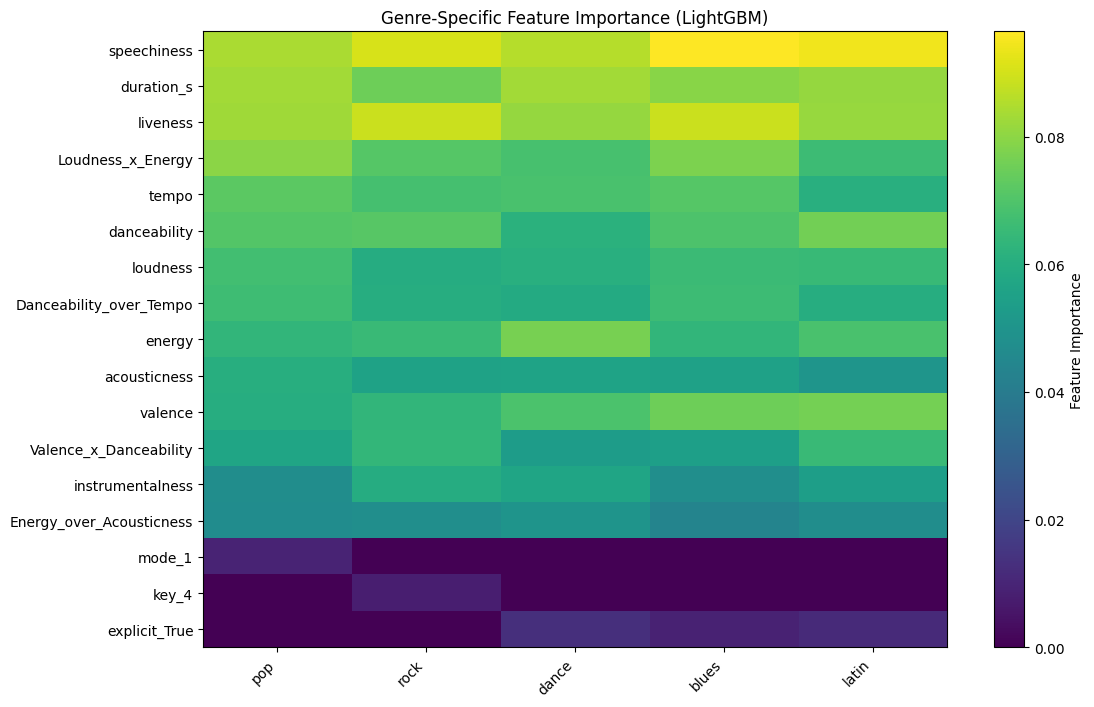

In [57]:
data = feature_importance_table.values
features = feature_importance_table.index.tolist()
genres = feature_importance_table.columns.tolist()

plt.figure(figsize=(12, 8))
plt.imshow(data, aspect="auto")
plt.colorbar(label="Feature Importance")

plt.yticks(np.arange(len(features)), features)
plt.xticks(np.arange(len(genres)), genres, rotation=45, ha="right")

plt.title("Genre-Specific Feature Importance (LightGBM)")

## 4. Directional Feature Analysis

**Goal**: understanding in **which direction** and **with what dynamics** the main features influence the probability of success, both globally and at the genre level.

The previous study only tells which features influence a song's success, for each analyzed genre; now it's useful to understand **which values for each feature** lead to a higher probability of success.

### SHAP Helper Functions

In [58]:
def compute_shap_values(model, X_sample, max_samples=3000):
    if len(X_sample) > max_samples:
        X_sample = X_sample.sample(max_samples, random_state=42)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    return shap_values, X_sample

In [59]:
def get_top_shap_features(shap_values, X_sample, top_n=10):
    shap_abs_mean = np.abs(shap_values).mean(axis=0)
    
    shap_importance = pd.Series(
        shap_abs_mean,
        index=X_sample.columns
    ).sort_values(ascending=False)

    return shap_importance.head(top_n).index.tolist()

### Global SHAP Summary (per genre)

SHAP Analysis (Top 10 features) for genre: pop


c:\Users\lucab\miniconda3\envs\damin2025\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


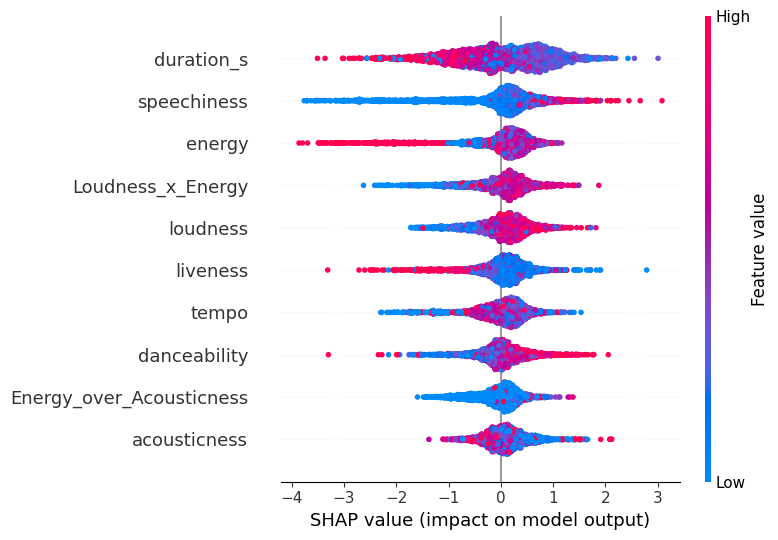

SHAP Analysis (Top 10 features) for genre: rock


c:\Users\lucab\miniconda3\envs\damin2025\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


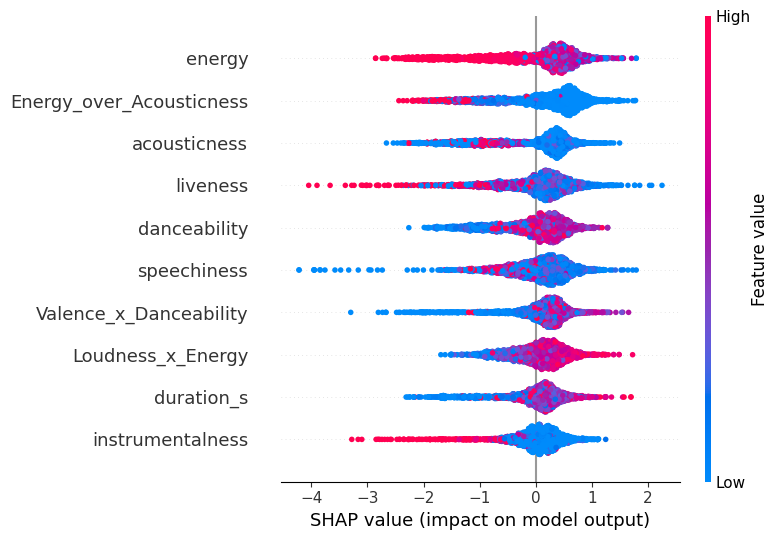

SHAP Analysis (Top 10 features) for genre: dance


c:\Users\lucab\miniconda3\envs\damin2025\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


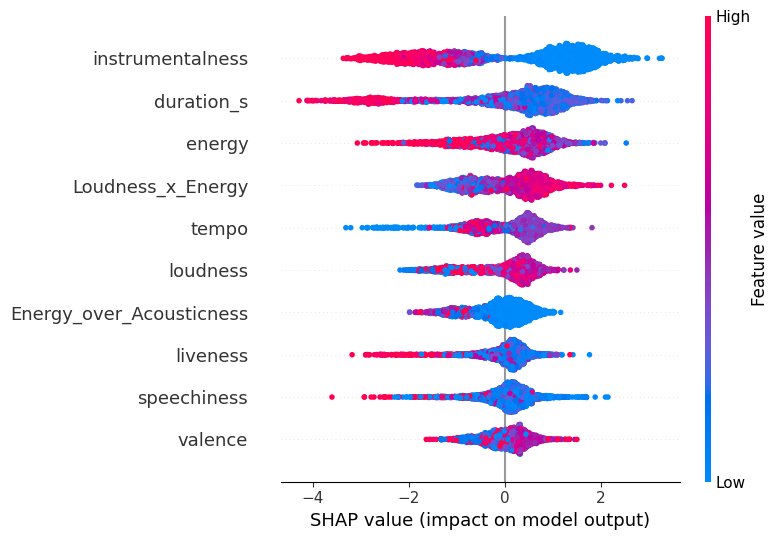

SHAP Analysis (Top 10 features) for genre: blues


c:\Users\lucab\miniconda3\envs\damin2025\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


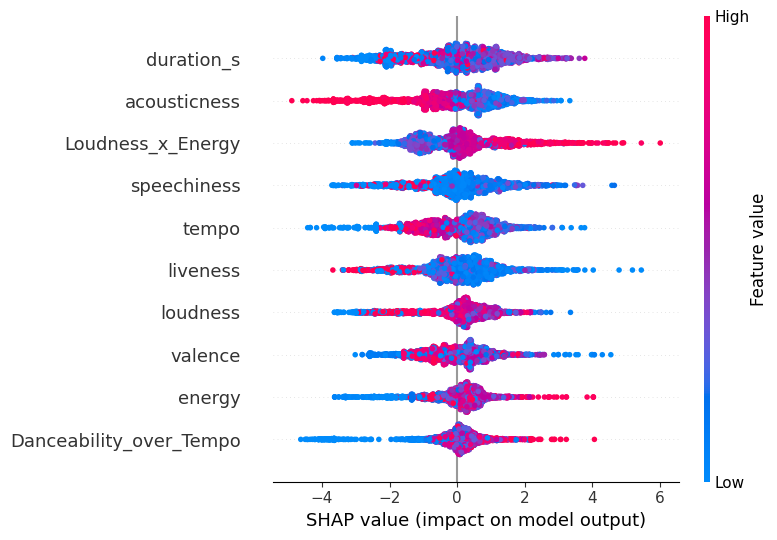

SHAP Analysis (Top 10 features) for genre: latin


c:\Users\lucab\miniconda3\envs\damin2025\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


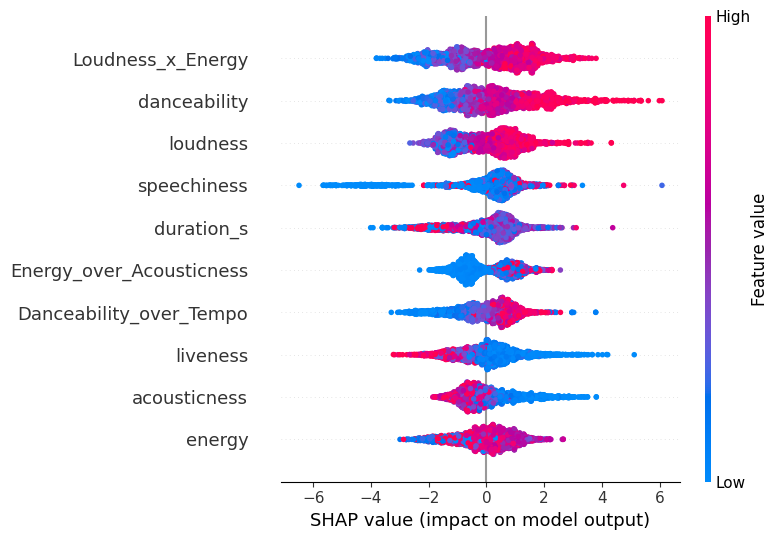

In [60]:
for genre in MAIN_GENRES:
    print(f"SHAP Analysis (Top 10 features) for genre: {genre}")

    model = genre_results[genre]["model"]
    X_train_g = genre_dataset_splits[genre]["X_train"]

    shap_values, X_sample = compute_shap_values(model, X_train_g)

    top10_features = get_top_shap_features(shap_values, X_sample, top_n=10)

    X_top10 = X_sample[top10_features]
    shap_top10 = shap_values[:, [X_sample.columns.get_loc(f) for f in top10_features]]

    shap.summary_plot(shap_top10, X_top10, title=genre, plot_type="dot", show=True,)